# FISTA Reconstruction Example

This notebook demonstrates sparse reconstruction using FISTA (Fast Iterative Shrinkage-Thresholding Algorithm).

FISTA minimizes ChiSquared + L1 regularization to recover sparse Faraday depth spectra.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from csromer.simulation import FaradayThinSource
from csromer.wrappers.reconstructors import CSROMERReconstructorWrapper
from csromer.utils.array_utils import maybe_compute

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source

In [2]:
# Create source
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,
    phi_gal=50.0,
    spectral_idx=-0.7,
)
source.simulate()
source.apply_noise(0.01, random_state=np.random.RandomState(42))

print(f"Source:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Flux: {source.s_nu:.3f} Jy")

Source:
  True RM: 50.00 rad/m²
  Flux: 0.100 Jy


## 2. Run FISTA Reconstruction

In [3]:
# Create FISTA reconstructor (MFISTA = monotone FISTA for stable descent)
source.l2_ref = 0.0
print(source.l2_ref)
recon = CSROMERReconstructorWrapper(
    dataset=source,
    oversampling=4.0,
    fista_maxiter=100,
    fista_tol=1e-5,
    fista_verbose=True,
    lambda_l_norm=0.5, 
)
recon.fista_monotonic = True  # MFISTA: reject steps that increase the objective

# Run reconstruction
recon.reconstruct()

print(f"\nReconstruction Results:")
print(f"  Dirty RM: {recon.rm_dirty:.2f} rad/m²")
print(f"  Model RM: {recon.rm_model:.2f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.2f} rad/m²")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")

0.0
FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.502
FISTA step: backtracking (FISTABacktracking)
Iteration: 0  objective: 1088.17661
Iteration: 10  objective: 12.69662
Iteration: 20  objective: 12.33972
Iteration: 30  objective: 12.07937
Iteration: 40  objective: 11.90220
Iteration: 50  objective: 11.72177
Iteration: 60  objective: 11.55411
Iteration: 70  objective: 11.41730
Iteration: 80  objective: 11.31494
Iteration: 90  objective: 11.24577
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve] kernel len=15 sum=4.228633 max=1.000000 (max=1, peak-conserving)
  [convolve] input x is None=False  peak|data_np|=6.392027e-03  sum|data_np|=4.838488e-01
[restore DEBUG]
  cellsize=3.878083  rmtf_fwhm=15.405924  pixels_per_rmtf=3.9726  amp_scale=1.3464
  peak:  dirty=9.976275e-02  model=6.392027e-03  residua

## 3. Visualize Results

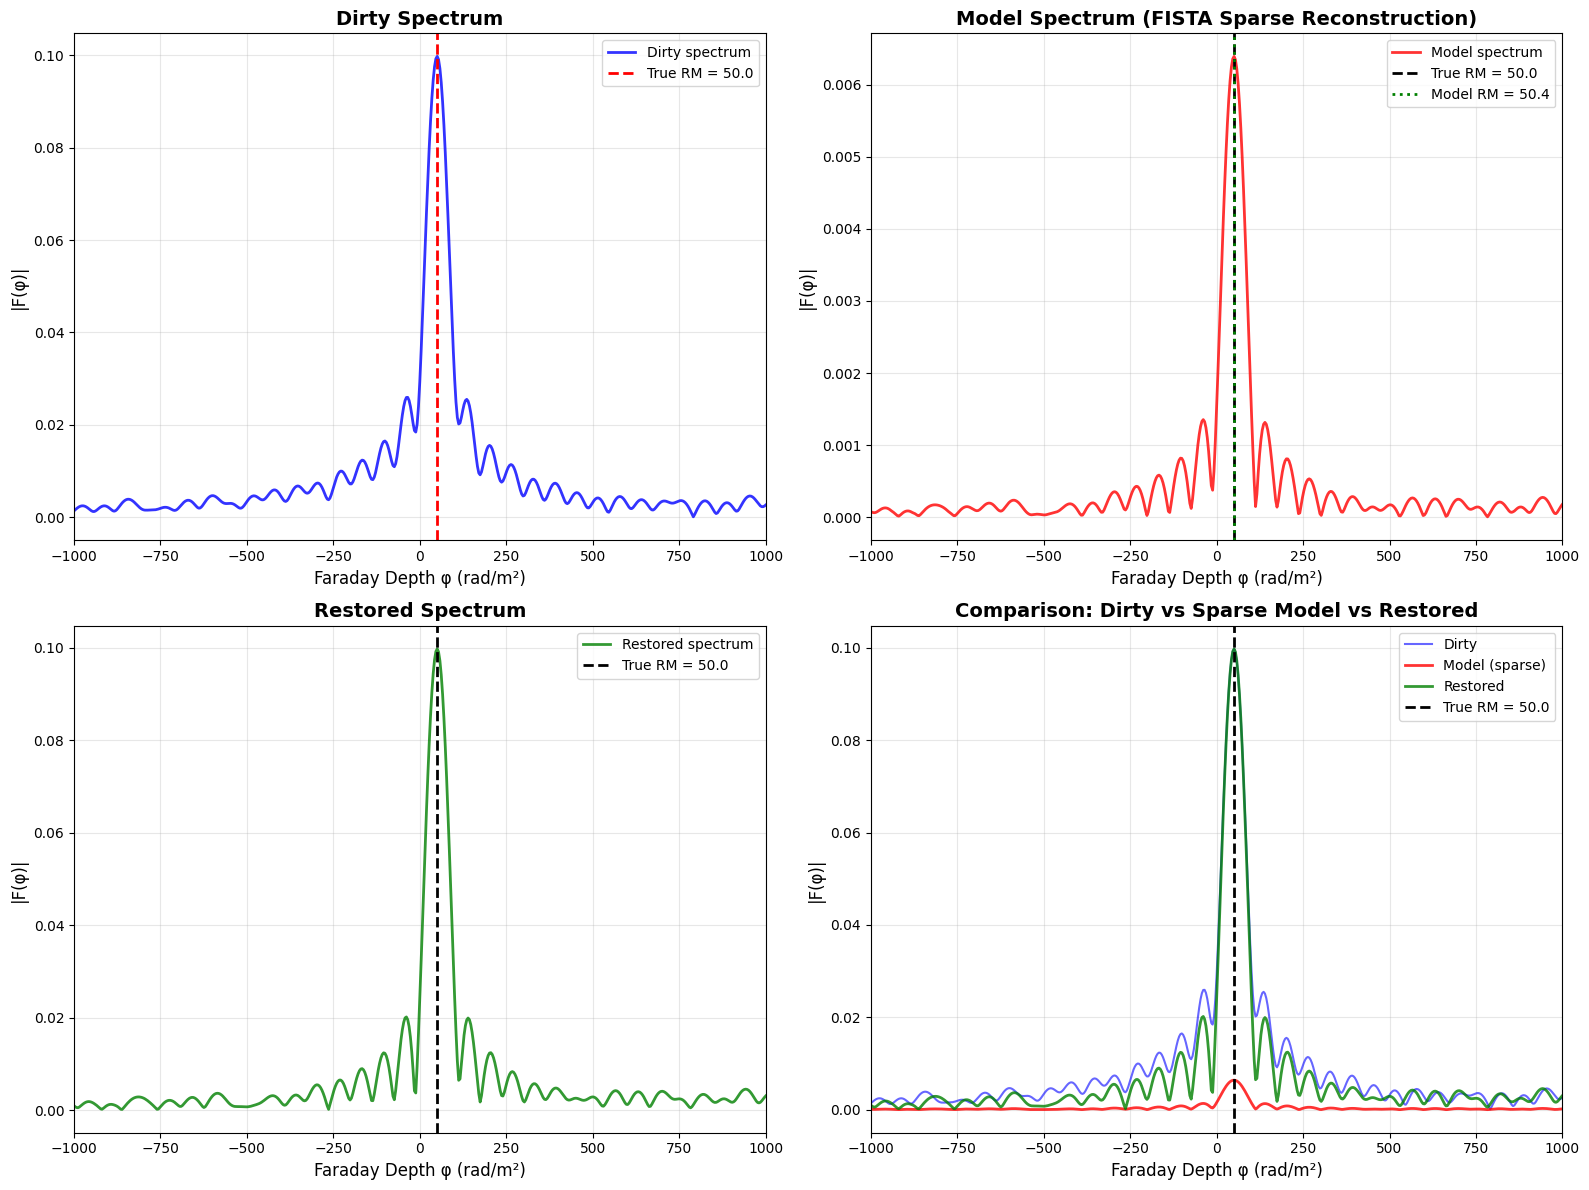


FISTA Reconstruction:
The model spectrum shows sparse reconstruction with L1 regularization.
This suppresses sidelobes and noise while preserving the main signal.


In [4]:
phi = np.asarray(maybe_compute(recon.parameter.phi))
fd_dirty = np.asarray(maybe_compute(recon.fd_dirty))
fd_model = np.asarray(maybe_compute(recon.fd_model))
fd_restored = np.asarray(maybe_compute(recon.fd_restored))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Dirty Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 2: Model spectrum (sparse reconstruction)
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axvline(recon.rm_model, color='g', linestyle=':', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (FISTA Sparse Reconstruction)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model (sparse)', alpha=0.8)
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Comparison: Dirty vs Sparse Model vs Restored', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

print("\nFISTA Reconstruction:")
print("The model spectrum shows sparse reconstruction with L1 regularization.")
print("This suppresses sidelobes and noise while preserving the main signal.")

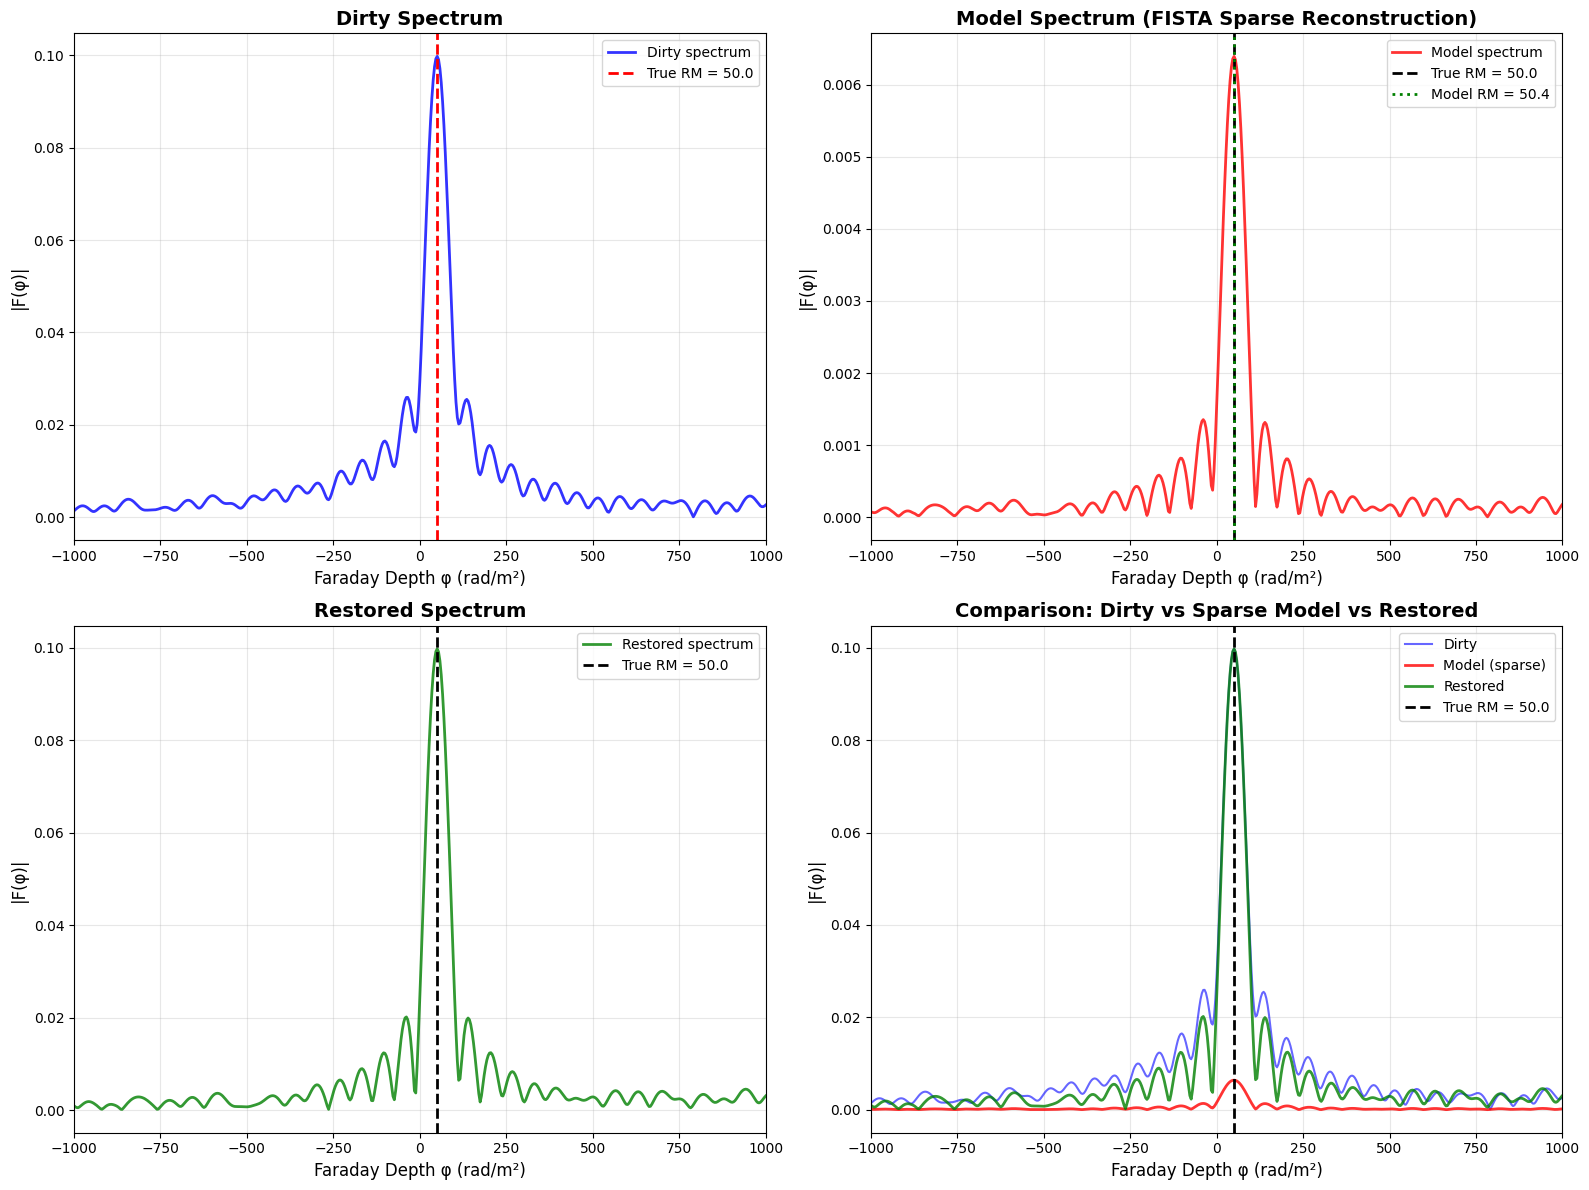


FISTA Reconstruction:
The model spectrum shows sparse reconstruction with L1 regularization.
This suppresses sidelobes and noise while preserving the main signal.


In [5]:
phi = np.asarray(maybe_compute(recon.parameter.phi))
fd_dirty = np.asarray(maybe_compute(recon.fd_dirty))
fd_model = np.asarray(maybe_compute(recon.fd_model))
fd_restored = np.asarray(maybe_compute(recon.fd_restored))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Dirty Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 2: Model spectrum (sparse reconstruction)
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.axvline(recon.rm_model, color='g', linestyle=':', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (FISTA Sparse Reconstruction)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model (sparse)', alpha=0.8)
ax.plot(phi, np.abs(fd_restored), 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Comparison: Dirty vs Sparse Model vs Restored', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

print("\nFISTA Reconstruction:")
print("The model spectrum shows sparse reconstruction with L1 regularization.")
print("This suppresses sidelobes and noise while preserving the main signal.")

## 4. Sparsity Analysis

Sparsity Analysis:
  Dirty spectrum: 104 significant points (>10% of peak)
  Model spectrum: 80 significant points (>10% of peak)
  Sparsity improvement: 1.3x


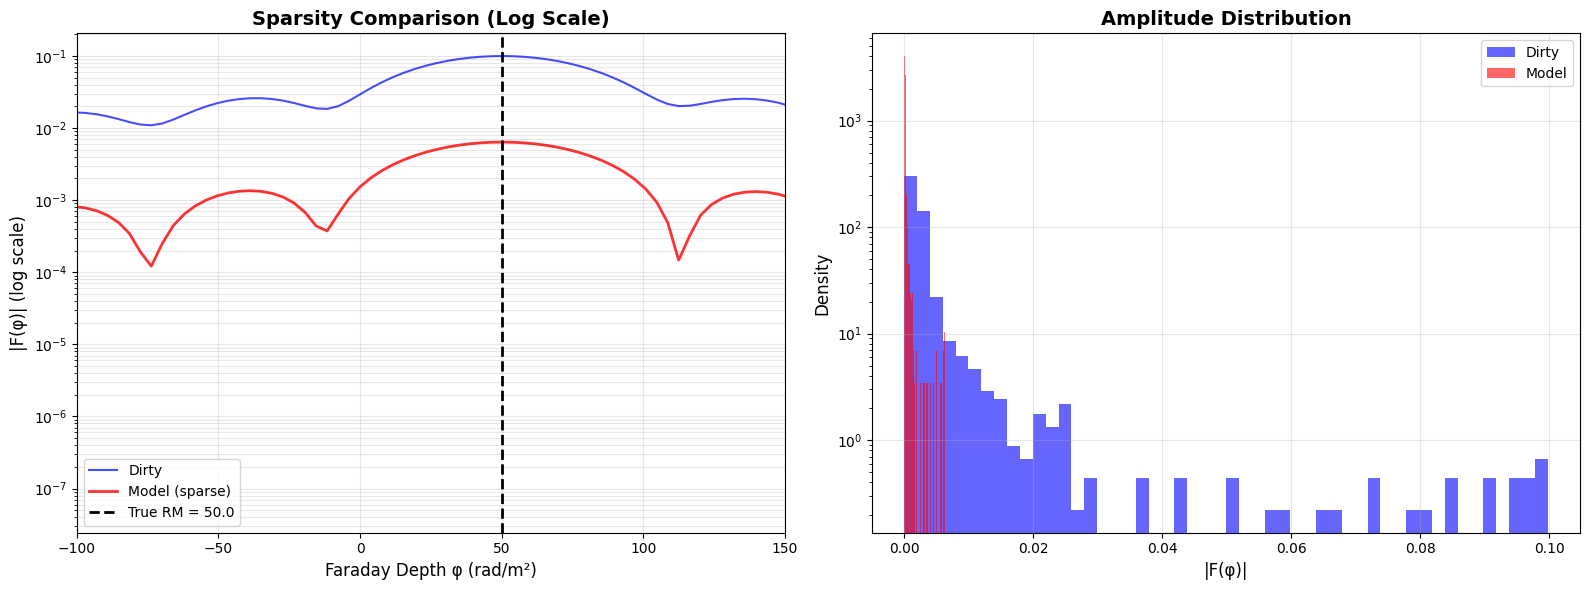

In [6]:
# Analyze sparsity
dirty_nonzero = np.sum(np.abs(fd_dirty) > np.max(np.abs(fd_dirty)) * 0.1)
model_nonzero = np.sum(np.abs(fd_model) > np.max(np.abs(fd_model)) * 0.1)

print("Sparsity Analysis:")
print(f"  Dirty spectrum: {dirty_nonzero} significant points (>10% of peak)")
print(f"  Model spectrum: {model_nonzero} significant points (>10% of peak)")
print(f"  Sparsity improvement: {dirty_nonzero / max(model_nonzero, 1):.1f}x")

# Plot sparsity comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log scale comparison
ax = axes[0]
ax.semilogy(phi, np.abs(fd_dirty) + 1e-10, 'b-', linewidth=1.5, label='Dirty', alpha=0.7)
ax.semilogy(phi, np.abs(fd_model) + 1e-10, 'r-', linewidth=2, label='Model (sparse)', alpha=0.8)
ax.axvline(source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}')
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)| (log scale)', fontsize=12)
ax.set_title('Sparsity Comparison (Log Scale)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(-100, 150)

# Histogram of amplitudes
ax = axes[1]
ax.hist(np.abs(fd_dirty), bins=50, alpha=0.6, label='Dirty', color='b', density=True)
ax.hist(np.abs(fd_model), bins=50, alpha=0.6, label='Model', color='r', density=True)
ax.set_xlabel('|F(φ)|', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Amplitude Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()